# Notebook 2: Preprocesamiento de Video y Extracción de Landmarks

Pasos:
1. Cargar manifest de segmentos (splits ya asignados)
2. Preprocesar videos → tensores .npy [T, H, W, C]
3. Extraer landmarks MediaPipe → .npy [T, N_kp, 3]
4. Verificar y visualizar resultados

In [1]:
# Dependencias ya instaladas en .venv310
# !pip install -q mediapipe opencv-python-headless scikit-learn tqdm ipywidgets
# !pip install -q torch torchvision


In [2]:
import os, sys, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Colab: {IN_COLAB}')

Colab: False


In [4]:
# Detecta Colab vs local automaticamente
if IN_COLAB:
    BASE_DIR = '/content/drive/MyDrive/TRADUCTOR_LSP'
else:
    BASE_DIR = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())

sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

from src.preprocessing.video_preprocessor import VideoPreprocessor
from src.preprocessing.landmark_extractor import LandmarkExtractor

print(f"BASE_DIR: {BASE_DIR}")
print("Modulos importados OK")

BASE_DIR: /Users/usuario/Documents/TRADUCTOR_LSP
Modulos importados OK


In [5]:
SEGMENTS_CSV = 'data/manifest_segments.csv'
df = pd.read_csv(SEGMENTS_CSV)

print(f'Total segmentos: {len(df):,}')
print('Distribucion de splits:')
print(df['split'].value_counts())
print('Videos unicos por split:')
print(df.groupby('split')['num_vineta'].nunique())
print('Clases en cada split:')
for split in ['train', 'val', 'test']:
    n = df[df['split']==split]['clase'].nunique()
    print(f'  {split}: {n} clases')

Total segmentos: 7,235
Distribucion de splits:
split
train    5051
test     1099
val      1085
Name: count, dtype: int64
Videos unicos por split:
split
test     26
train    26
val      26
Name: num_vineta, dtype: int64
Clases en cada split:
  train: 26 clases
  val: 26 clases
  test: 26 clases


In [6]:
# Pre-cache de pixels: 1 .npy por VIDEO para verificar que OpenCV
# puede abrir y redimensionar todos los videos.
# En entrenamiento, LSPVideoDataset lee cada segmento on-the-fly
# usando start_frame/end_frame desde el video original.
preprocessor = VideoPreprocessor(
    height=224, width=224, n_frames=30, target_fps=25.0,
    imagenet_norm=True, use_decord=False,
)

PIXELS_DIR = 'data/processed_pixels'
os.makedirs(PIXELS_DIR, exist_ok=True)

videos_unicos = df['video_path'].unique()
errors_pixels = []

print(f'Verificando {len(videos_unicos)} videos...')
for vp in tqdm(videos_unicos):
    out_path = os.path.join(PIXELS_DIR, f"{Path(vp).stem}.npy")
    if os.path.exists(out_path):
        continue
    try:
        arr = preprocessor.process(vp)
        np.save(out_path, arr)
    except Exception as e:
        errors_pixels.append({'video': vp, 'error': str(e)})

print(f'Procesados: {len(os.listdir(PIXELS_DIR))} archivos .npy')
if errors_pixels:
    print(f'Errores: {len(errors_pixels)}')
    print(errors_pixels[:3])

Verificando 26 videos...


  0%|          | 0/26 [00:00<?, ?it/s]

Procesados: 26 archivos .npy


Shape: (30, 224, 224, 3)
Dtype: float32
Min/Max: -2.118 / 2.640


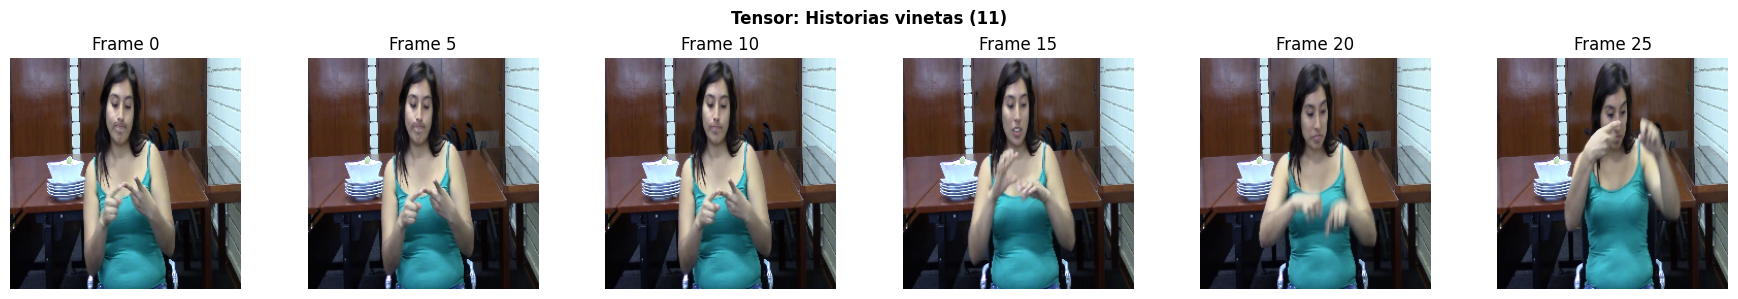

In [8]:
sample_npy = sorted(Path(PIXELS_DIR).glob('*.npy'))[0]
arr = np.load(sample_npy)

print(f'Shape: {arr.shape}')  # esperado: (30, 224, 224, 3)
print(f'Dtype: {arr.dtype}')
print(f'Min/Max: {arr.min():.3f} / {arr.max():.3f}')

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    frame_idx = int(i * len(arr) / 6)
    frame = np.clip(arr[frame_idx] * std + mean, 0, 1)
    ax.imshow(frame)
    ax.set_title(f'Frame {frame_idx}')
    ax.axis("off")
plt.suptitle(f'Tensor: {sample_npy.stem}', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
extractor = LandmarkExtractor(
    use_pose=True, use_face=False,
    normalize_wrist=True, target_fps=25.0,
)

LANDMARKS_DIR = 'data/landmarks'
os.makedirs(LANDMARKS_DIR, exist_ok=True)

# Extraer landmarks por SEGMENTO (start_frame..end_frame de cada fila)
# Guarda 1 .npy por segmento: {clase}_s{start:06d}_kp.npy
# Actualiza la columna kp_path en manifest_segments.csv
errors_kp = []
print(f'Extrayendo landmarks para {len(df)} segmentos...')
print('Esto puede tardar varios minutos.')

for i, row in tqdm(df.iterrows(), total=len(df)):
    kp_fname = f"{row['clase']}_s{row['start_frame']:06d}_kp.npy"
    out_path = os.path.join(LANDMARKS_DIR, kp_fname)
    if os.path.exists(out_path):
        df.at[i, 'kp_path'] = out_path
        continue
    try:
        seq = extractor.extract(
            row['video_path'],
            n_frames=30,
            start_frame=int(row['start_frame']),
            end_frame=int(row['end_frame']),
        )
        np.save(out_path, seq)
        df.at[i, 'kp_path'] = out_path
    except Exception as e:
        errors_kp.append({'seg': out_path, 'error': str(e)})

# Actualizar manifest con kp_path
df.to_csv(SEGMENTS_CSV, index=False)

n_ok = len([f for f in os.listdir(LANDMARKS_DIR) if f.endswith('_kp.npy')])
print(f'Landmarks guardados: {n_ok} archivos')
if errors_kp:
    print(f'Errores: {len(errors_kp)}')
    print(errors_kp[:3])

Extrayendo landmarks para 7235 segmentos...
Esto puede tardar varios minutos.


  0%|          | 0/7235 [00:00<?, ?it/s]

Landmarks guardados: 7235 archivos


Shape landmarks: (30, 75, 3)
Dtype: float32
% frames mano activa: 0.0%


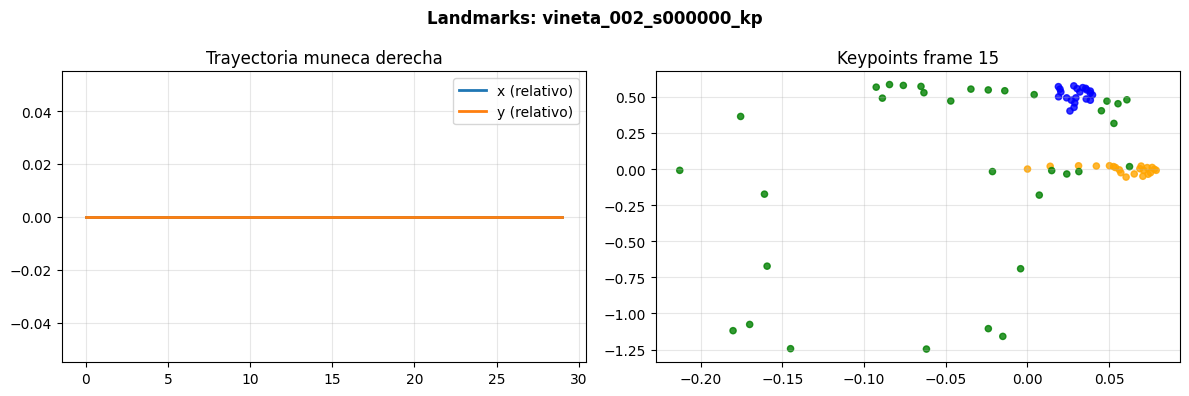

Colores: Azul=Mano izq, Naranja=Mano der, Verde=Pose


In [10]:
sample_kp = sorted(Path(LANDMARKS_DIR).glob('*.npy'))[0]
seq = np.load(sample_kp)

print(f'Shape landmarks: {seq.shape}')  # esperado: (30, 75, 3)
print(f'Dtype: {seq.dtype}')
print(f'% frames mano activa: {(seq[:,:42,:].sum(axis=(1,2)) > 0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wrist_r = seq[:, 21, :]
axes[0].plot(wrist_r[:, 0], label='x (relativo)', linewidth=2)
axes[0].plot(wrist_r[:, 1], label='y (relativo)', linewidth=2)
axes[0].set_title('Trayectoria muneca derecha')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

mid_frame = seq[15]
colors = ['blue']*21 + ['orange']*21 + ['green']*33
axes[1].scatter(mid_frame[:, 0], -mid_frame[:, 1],
                c=colors[:len(mid_frame)], s=20, alpha=0.8)
axes[1].set_title('Keypoints frame 15')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Landmarks: {sample_kp.stem}', fontweight='bold')
plt.tight_layout()
plt.show()
print('Colores: Azul=Mano izq, Naranja=Mano der, Verde=Pose')

Calidad:   0%|          | 0/200 [00:00<?, ?it/s]

Mano activa — Media: 86.8%  Min: 0.0%
>80% activas: 80.5% de videos


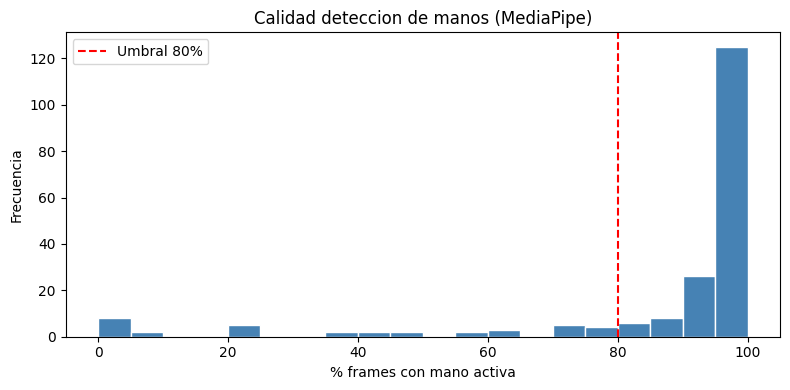

In [11]:
all_kp_files = sorted(Path(LANDMARKS_DIR).glob('*.npy'))
mano_activa_pct = []
for kp_path in tqdm(all_kp_files[:200], desc='Calidad'):
    seq = np.load(kp_path)
    activo = (seq[:, :42, :].sum(axis=(1,2)) != 0).mean() * 100
    mano_activa_pct.append(activo)

mano_activa_pct = np.array(mano_activa_pct)
print(f'Mano activa — Media: {mano_activa_pct.mean():.1f}%  Min: {mano_activa_pct.min():.1f}%')
print(f'>80% activas: {(mano_activa_pct > 80).mean()*100:.1f}% de videos')

plt.figure(figsize=(8, 4))
plt.hist(mano_activa_pct, bins=20, color='steelblue', edgecolor='white')
plt.axvline(80, color='red', linestyle='--', label='Umbral 80%')
plt.xlabel('% frames con mano activa')
plt.ylabel('Frecuencia')
plt.title('Calidad deteccion de manos (MediaPipe)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
print('Preprocesamiento completado.')
print('  Pixels:    data/processed_pixels/')
print('  Landmarks: data/landmarks/')
print(f'  Manifest:  {SEGMENTS_CSV}')
print('Siguiente paso: Notebook 03 Entrenamiento')

Preprocesamiento completado.
  Pixels:    data/processed_pixels/
  Landmarks: data/landmarks/
  Manifest:  data/manifest_segments.csv
Siguiente paso: Notebook 03 Entrenamiento
